# TS1: Síntesis y operaciones de señales
### Gonzalo Constenla

[Nbviewer](https://nbviewer.org/github/GConstenlaP/AyPS/blob/main/TS1/TS1.ipynb) EDITAR

En el presente trabajo se sintetiza una señal sinusoidal, se simula ruido de señal y se analiza el proceso de digitalizacion de dicha señal a traves de la simulación de un conversor analogico digital ADC de B bits.


### Marco Teórico
El proceso de conversion analógico digital, constituye ademas del muestreo temporal visto anteriormente, la cuantización de amplitud. La cuantización introduce el error de cuantización $e$, acotado por:
$$e \in [-q/2 : q/2]$$
donde $q$ es el paso de cuantización o resolución dle conversor, y representa la distancia entre un nivel y el siguiente de los posibles valores en amplitud (V) de las muestras de la señal.

El paso de cuantizacion es calculado por:

$$q = (2*Vf) / (2**B) $$

Donde $Vf$ es el limite del rango de escala completa (full scale) del ADC: $[-V_F, +V_F]$ y representa el limite de máximo de tension que el ADC soporta. B representa los B-bits, es decir la cantidad de bits de resolución del ADC.

El error de cuantización puede expresarse estadísticamente como la *potencia media del ruido de cuantizacion* Prq:  $Prq = q**2/12$

Luego para modelar un posible ruido analógico de una señal de entrada real, se introduce una variable aleatoria de distribucion normal que representa dicho ruido (*R*) expresado:

$$
R \sim \mathcal{N}(\mu,\sigma^2)
$$

Donde la media es $\mu = 0$ y la varianza: $ \sigma^2 = Pra$. La varianza usada $Pra$ equivale a la potencia de la señal de ruido y esta se definio tomando de referencia una escala $K$ y la potencia del error de cuantización $Prq$ según:

$$Pra = Prq * K$$

De forma que la potencia del ruido analógico queda definido por la potencia del error de cuantización y se puede analizar el impacto del ruido analógico en relacion al error de cuantizacion generado por el ADC.


### Desarrollo
Importo librerias a utilizar, defino algunos parametros e introduzco la señal original: senoidal de energia normalizada y varianza unitaria y por lo tanto ampltud: $A1 = squareroot(2)$:

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scipy


N = 1000            #muestras
fs = 1000           #frecuencia de muestreo del ADC


f0 = fs/N           #frecuencia señal FUNCION DE FS Y N 
delta_f = fs / N    #f0 = fs/N = delta_f, densidad espectral
    
n = np.arange(N)

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):

    tt = np.arange(nn) / fs

    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx


A1 = np.sqrt(2)
T, X = mi_funcion_sen(vmax=A1, dc=0, ff=f0, ph=0, nn=N, fs=fs)


Introduzco Ruido Incorrelado y Gaussiano, para el cual uso np.random.normal que es definido a partir de la potencia del error de cuantizacion escalado por K = 1, de esta forma genero un ruido analogico con igual potencia al ruido de cuantización.



Luego defino La señal analogica de entrada como la suma de la señal original y el ruido generados y además realizo y grafico el proceso de cuantizacion que es simulado obteniendo el valor mas cercano a la señal y es devuelto a al escala de voltios multiplicando el resultado por el paso de cuantizacion q.



#### Punto A: SEÑAL 1

<function matplotlib.pyplot.show(close=None, block=None)>

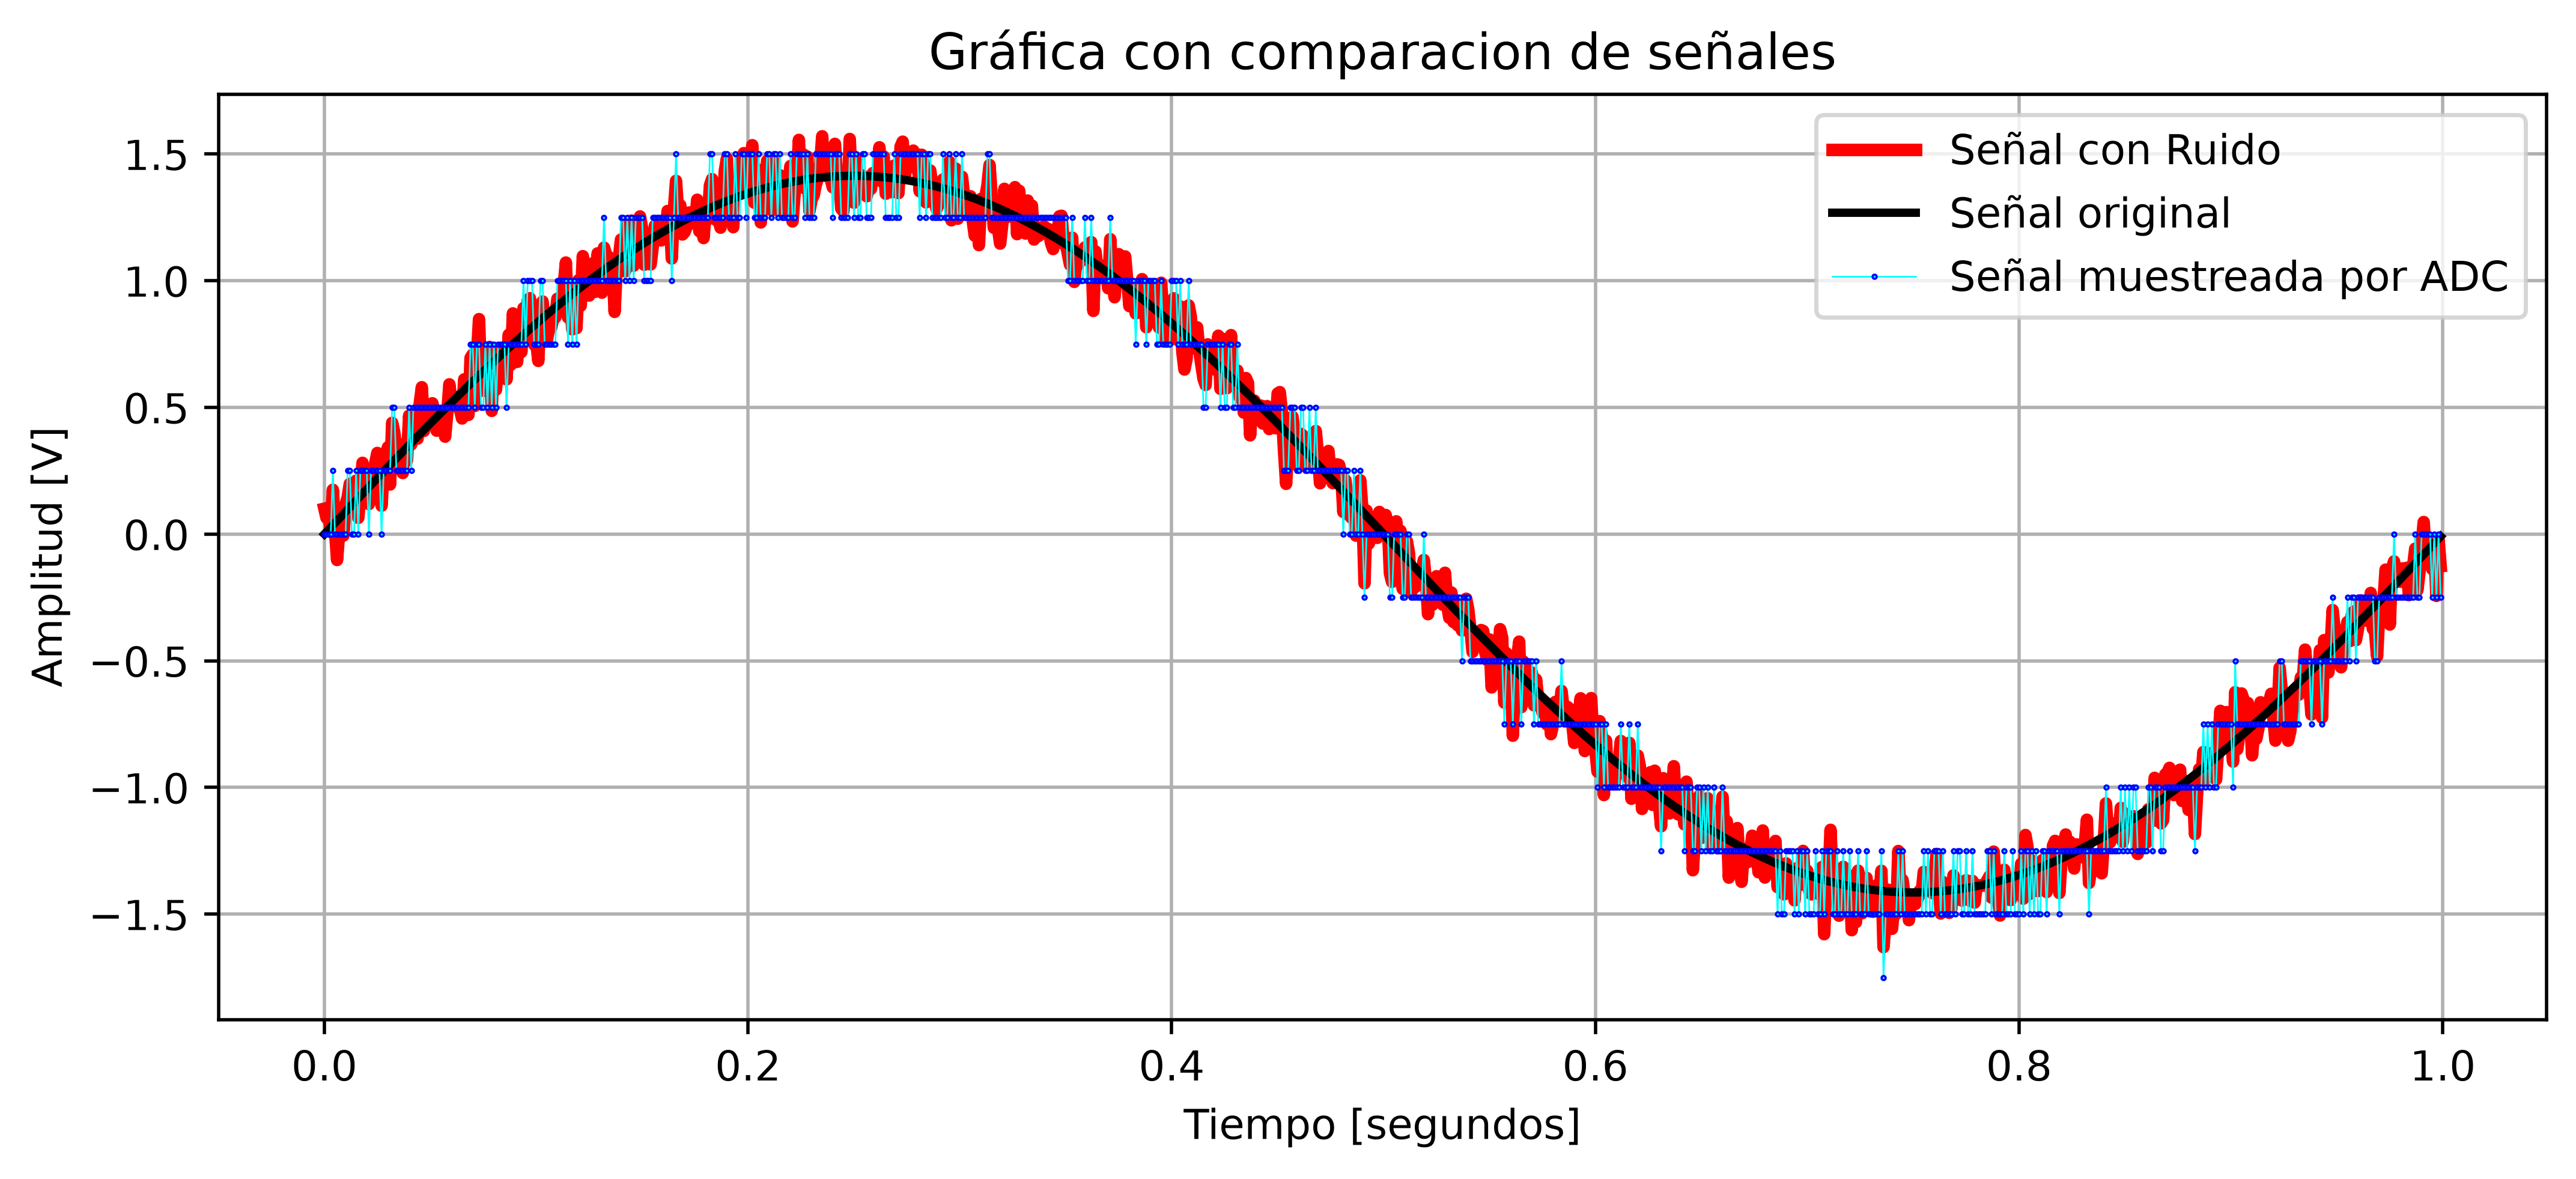

In [2]:
def gen_noise_normal(media=0, varianza=0.1, nn=N):

    desv_est = np.sqrt(varianza) #sigma

    ruido_normal = np.random.normal(media, desv_est, nn)
    return ruido_normal

    
Vf = 2
#paso de cuantizacion q, con B bits = 4 es q = 0,25V
B = 4
q = (2*Vf) / (2**B)         # q paso de cuantizacion: q = 2*Vf / 2**B........ q(Resolucion del ADC o Paso de cuantizacion)= Rango total/ Niveles

Prq = (q**2) / 12       
K = 1
Pra = Prq * K # #Potencia de Ruido analogico.
R = gen_noise_normal(varianza=Pra)

# Señal con Ruido
XR = X + R

XRQ = np.round(XR / q) * q


plt.figure(figsize=(10, 4), dpi=500)
plt.plot(T, XR, color = 'red', label = 'Señal con Ruido', linewidth=3)
plt.plot(T, X, color = 'black', label = 'Señal original', linewidth=2)
plt.plot(T, XRQ, color = 'cyan', label = 'Señal muestreada por ADC', linewidth=0.4, marker='o', markersize=1, markeredgecolor='blue', markeredgewidth=0.5)
#alpha es la opacidad, 
plt.title('Gráfica con comparacion de señales')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.legend(loc='best')
plt.show


### Gráfica de Densidad espectral

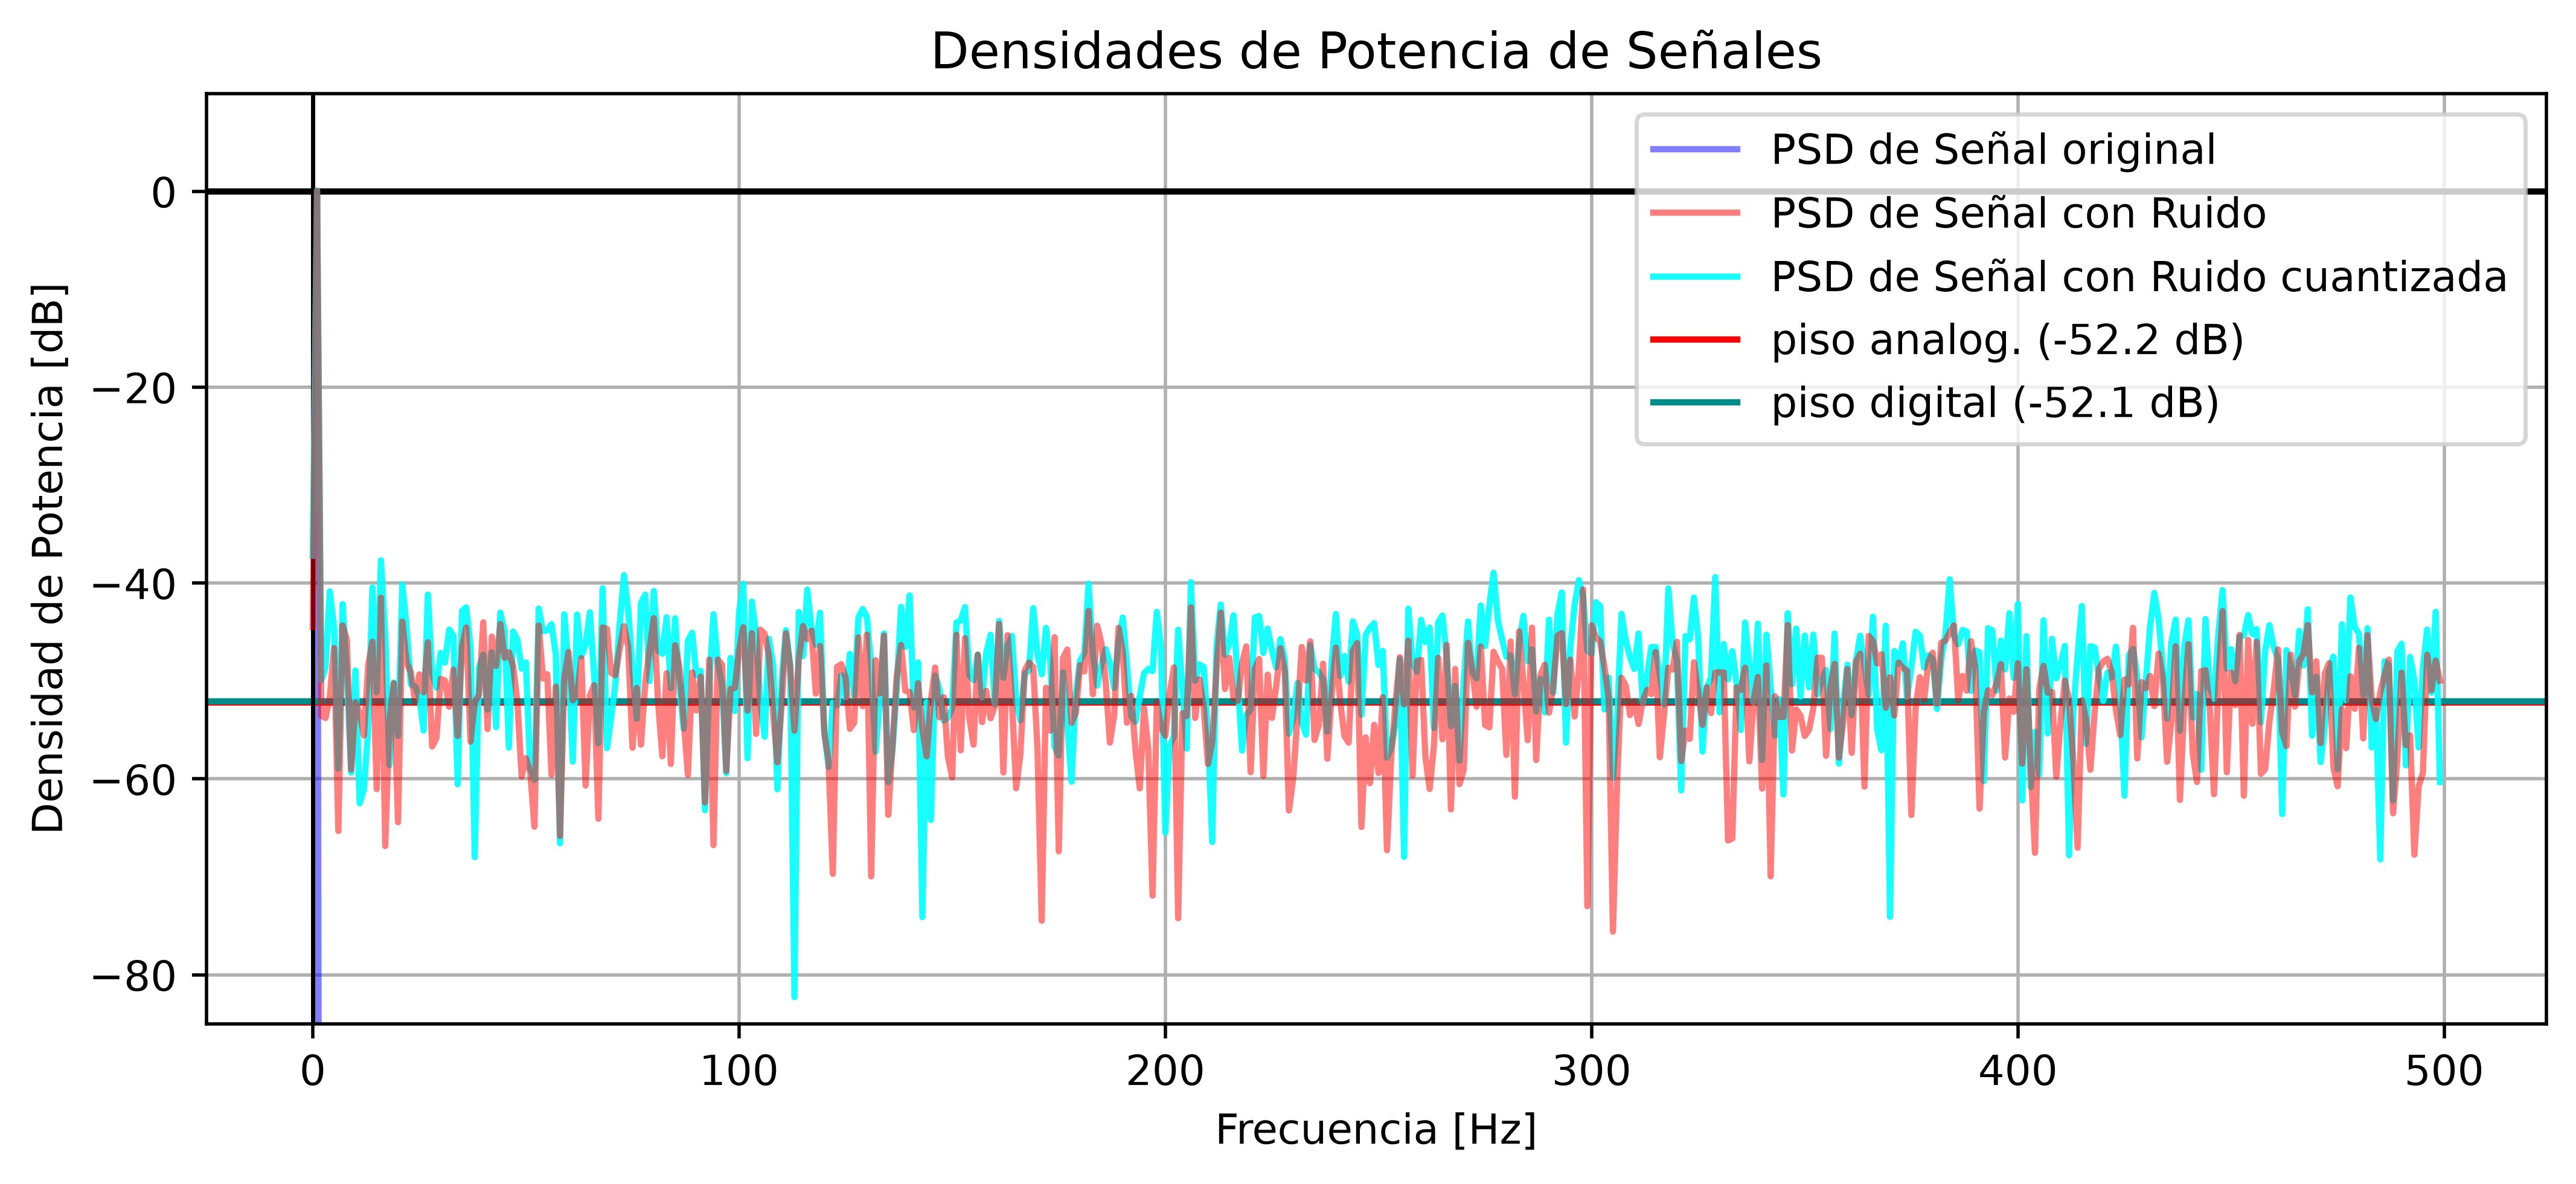

In [9]:

#FFTs normalizadas por N
fft_X= scipy.fft.fft(X)
modulo_X_norm = np.abs(fft_X)/N


fft_XR= scipy.fft.fft(XR)
modulo_XR_norm = np.abs(fft_XR)/N


fft_XRQ= scipy.fft.fft(XRQ)
modulo_XRQ_norm = np.abs(fft_XRQ)/N



# A partir de Ahora graficare solo el rango de (0, fs/2)
frecuencias = np.arange(0, fs/2, fs/N)
frecuencias = frecuencias[:N//2]

#Escalo para que el pico max de amplitud de la señal original coincida con el 0
#Normalizacion de Señal respecto a amplitud maxima
Max1 = np.max(modulo_X_norm)

#modulo de fft normalizado con maximo
PSD_X = modulo_X_norm/Max1
PSD_XR = modulo_XR_norm/Max1
PSD_XRQ = modulo_XRQ_norm/Max1


# Magnitud espectral relativa en db
PSD_X_db = 20*np.log10((modulo_X_norm/Max1) + 1e-12)
PSD_XR_db = 20*np.log10((modulo_XR_norm/Max1) + 1e-12)
PSD_XRQ_db = 20*np.log10((modulo_XRQ_norm/Max1) + 1e-12)

#El piso analogico ñ es el valor medio del ruido (analogico) gaussiano que se agrega a la señal  antes de pasar por el adc
# El piso Digital ÑQ es el valor medio de potencia del error de cuantizacion Eq = XRQ - XR


#Error de cuantizacion
eq = XRQ - XR
fft_eq = scipy.fft.fft(eq) / N
modulo_eq_norm = np.abs(fft_eq[:N//2])
PSD_eq_db = 20 * np.log10((modulo_eq_norm  / Max1) + 1e-12)

piso_analog  = np.mean(PSD_XR_db[2:])
piso_digital = np.mean(PSD_eq_db)

plt.figure(figsize=(10, 4), dpi=500)
plt.plot(frecuencias, PSD_X_db[:N//2], color ='Blue', alpha = 0.5, zorder = 2, label = 'PSD de Señal original')
plt.plot(frecuencias, PSD_XR_db[:N//2], color = 'Red', alpha = 0.5, zorder = 4, label = 'PSD de Señal con Ruido')
plt.plot(frecuencias, PSD_XRQ_db[:N//2], color = 'Cyan', alpha = 0.9, zorder = 3, label = 'PSD de Señal con Ruido cuantizada')

#lineas de piso de Ruido
plt.axhline(piso_analog, color='red', linestyle='-', label=f'piso analog. ({piso_analog:.1f} dB)')
plt.axhline(piso_digital, color='darkcyan', linestyle='-', label=f'piso digital ({piso_digital:.1f} dB)')

plt.title("Densidades de Potencia de Señales")
plt.ylabel("Densidad de Potencia [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid()
plt.ylim(-85, 10)
plt.legend(loc='best')
plt.axhline(0,color="black")
plt.axvline(0,color="black",linewidth=1)


### Analisis del error de cuantizacion

### Histograma dle ruido de cuantizacion
El histograma es una forma de representar la probabilidad experimental del error de cuantizacion que introduce el ADC, viendo el grafico podemos ver si se aproxima a una variable aleatoria de distribucion uniforme o si se aleja, pero no es suficiente para determinar.
Para una distribucion uniforme ideal, todas las barras deberian tener la misma altura, es decir deberia haber la misma cantidad de muestras en cada valor de amplitud de error,


El modelo teorico espera que eq se encuentre estrictamente en el intervalo: [-q/2, q/2]


Error del ruido de cuantizacion
# Histograma del error
# Error de cuantizacion eq = XRQ - XR


plt.figure()
plt.hist(eq, edgecolor='black')
plt.title('Histograma del ruido de cuantización')
plt.xlabel('Magnitud del error del Ruido de cuantizacion')
plt.ylabel('Cantidad de muestras')
plt.grid()


# reviso minimo y maximo de nq, no deberia encontrar valoresmuy lejos de ±qq/2 
print("mínimo:", np.min(eq)) #en V
print("máximo:", np.max(eq))
print("El paso de cuantizacion es:", q)


# Con Q = 0,25, el rango del erri es -q/2 y q/2 = [-0,125, 0,125]

#Varianza

var_real = np.var(eq)
var_teorica = (q**2) / 12
print("El paso de cuantizacion es:", q) # V
print("Varianza experimental:", var_real)
print("Varianza teórica:", var_teorica)



### AUTOCORRELACION Y TEST KOLMOGOROV SMIRNOV

Autocorrelacion

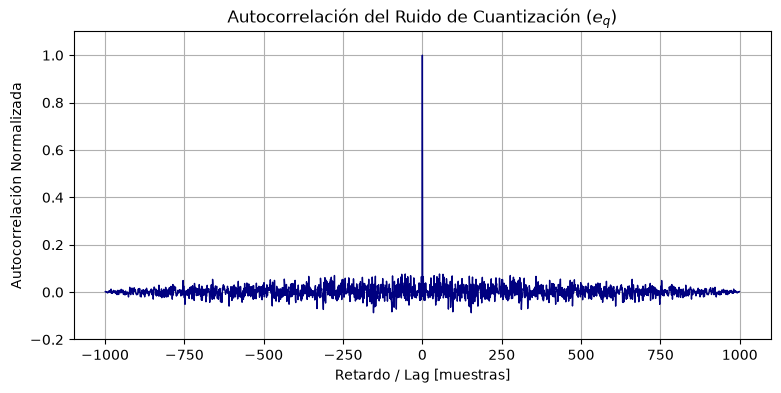

In [10]:
# %% Autocorrelacion 
autocorr = np.correlate(eq, eq, mode='full')
lags = np.arange(-N + 1, N)

# Normalización respecto al pico central (lag 0)
autocorr_norm = autocorr / np.max(autocorr)

plt.figure(figsize=(9, 4))
plt.plot(lags, autocorr_norm, color='navy', linewidth=1)
plt.title('Autocorrelación del Ruido de Cuantización ($e_q$)')
plt.xlabel('Retardo / Lag [muestras]')
plt.ylabel('Autocorrelación Normalizada')
plt.grid(True)
plt.ylim(-0.2, 1.1)
plt.show()

El Test de Kolmogórov-Smirnov es un método estadístico para determinar si la muestra de datos evaluada pertenece a una distribucion de probabilidad teorica determinada o si la muestra no se ajusta a dicha distribución o si las muestras corresponden a distribuciones distintas.
Calcula la función de distribución empírica y la compara con la función de distribución acumulada teórica para determinar un resultado.

En este análisis, los posibles resultados son: 

Hipotesis Nula, H0: Los datos del error de cuantizacion (EQ) siguen una distribución normal

Hipótesis Alternativa , H1: Los datos no siguen una distribución normal

Para determinar el resultado se define el P-Valor y:

Si p > 0,05, No rechazo H0

Si p ≤ 0,05, Rechazo H0



In [13]:
from scipy.stats import kstest

a = -q / 2
b = q / 2
ancho_intervalo = b - a # = q

resultado_ks = kstest(eq, 'uniform', args=(a, ancho_intervalo))

print("K-S:", resultado_ks.statistic) #Es el estadístico \(D\) de Kolmogorov-Smirnov y me devuelve la maxima separacion obtenida entre ambas funciones acumuladas
print("p-value:", resultado_ks.pvalue)


alpha = 0.05
if resultado_ks.pvalue > alpha:
    print("No se rechaza H0. El error se comporta como una distribución Uniforme [-q/2, q/2].")
else:
    print("Se rechaza H0. El error NO sigue una distribución uniforme.")
    

K-S: 0.05196346922127659
p-value: 0.008704037222986837
Se rechaza H0. El error NO sigue una distribución uniforme.
